In [ ]:
"""
Cross-domain evaluation (A to D) on MALDI-TOF data.

Source domain: DRIAMS_A
Target domain: DRIAMS_D

A Multi-Decoder VAE is trained using A and D (train + val splits only).

A Random Forest classifier is trained on A and evaluated on D.

Comparison:
- Original space (X)
- Latent space (z)

Objective: assess whether the latent representation reduces domain shift.

D_test is strictly held out and never used during training.
"""

## Path configuration

In [33]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [ ]:
import pickle
import numpy as np
import pandas as pd

# utils
from src.config.loader import *
from src.data.datasets import *
from src.data.preprocessing import *
from src.evaluation.metrics import *
from src.visualization.viz import *

# models
from sklearn.ensemble import RandomForestClassifier

## Data loading

In [35]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL2"]
driams = load_pkl(driams_pkl)

data, label, raw_meta = driams["data"], driams["label"], driams["meta"]

# Normalize each spectrum independently to [0, 1]
X_min = data.min(axis=1, keepdims=True)
X_max = data.max(axis=1, keepdims=True)
data_norm = (data - X_min) / (X_max - X_min + 1e-8)

meta = pd.DataFrame.from_records(list(raw_meta))

In [36]:
# Select domains 
source_domain = "DRIAMS_A"
target_domain = "DRIAMS_D"

selected_domains = [source_domain, target_domain]

data_list, label_list, meta_list = [], [], []

for hosp in selected_domains:
    idx = np.where(meta["hospital"].values == hosp)[0]
    data_list.append(data_norm[idx])
    label_list.append(label[idx])
    meta_list.append(meta.iloc[idx])

data_final = np.vstack(data_list)
label_final = np.concatenate(label_list)
meta_final = pd.concat(meta_list, ignore_index=True).reset_index(drop=True)

domain_ids_final = map_domains(meta_final)

In [37]:
# Load splits
experiment_dir = Path("/export/usuarios01/agnavarr/MALDIAlign/experiments/results/vae_multidecoder/20260324_121404")
splits_path = experiment_dir / "data_splits.pkl"

with open(splits_path, "rb") as f:
    splits = pickle.load(f)

In [40]:
# Extract splits
# Source domain
train_idx_A = splits["splits_per_domain"][source_domain]["train_idx"]
val_idx_A   = splits["splits_per_domain"][source_domain]["val_idx"]
test_idx_A  = splits["splits_per_domain"][source_domain]["test_idx"]

# Target domain
test_idx_D  = splits["splits_per_domain"][target_domain]["test_idx"]

# Build datasets
# Source training data
X_train = data_final[train_idx_A]
y_train = label_final[train_idx_A]
domain_train = domain_ids_final[train_idx_A]

# Source validation data
X_val = data_final[val_idx_A]
y_val = label_final[val_idx_A]
domain_val = domain_ids_final[val_idx_A]

# In-domain test (sanity check only)
X_A_test = data_final[test_idx_A]
y_A_test = label_final[test_idx_A]
domain_A_test = domain_ids_final[test_idx_A]

# Cross-domain test
X_D_test = data_final[test_idx_D]
y_D_test = label_final[test_idx_D]
domain_D_test = domain_ids_final[test_idx_D]

print(f"Train (A): {X_train.shape}")
print(f"Val (A): {X_val.shape}")
print(f"Test A (in-domain): {X_A_test.shape}")
print(f"Test D (cross-domain): {X_D_test.shape}")

Train (A): (19467, 6000)
Val (A): (2781, 6000)
Test A (in-domain): (5562, 6000)
Test D (cross-domain): (1462, 6000)


## Original space

### Train

In [42]:
rf_original = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_original.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Test


===== Metrics =====
Domain: A (in-domain)
Balanced Accuracy: 0.9982
F1 Macro: 0.9986
Recall Macro: 0.9982
Specificity Macro: 0.9997



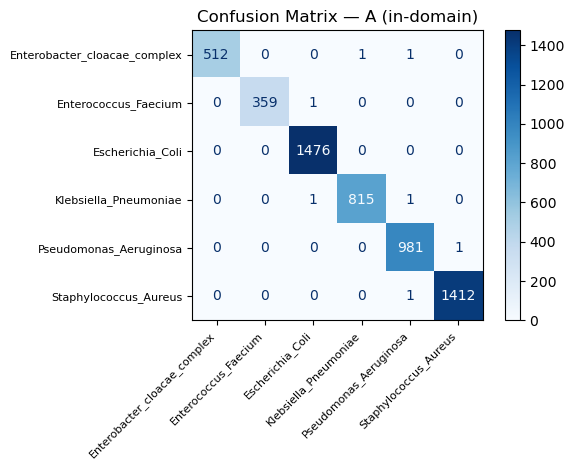


===== Metrics =====
Domain: D (cross-domain)
Balanced Accuracy: 0.9125
F1 Macro: 0.8973
Recall Macro: 0.9125
Specificity Macro: 0.9784



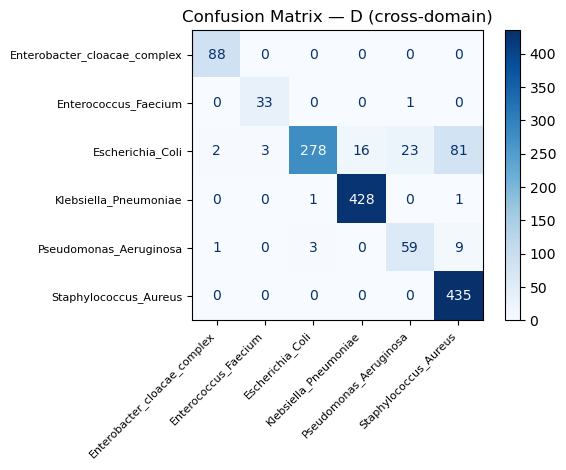

In [43]:
metrics_A = metrics_report(X_A_test, y_A_test, rf_original, "A (in-domain)")
metrics_D = metrics_report(X_D_test, y_D_test, rf_original, "D (cross-domain)")

print_metrics(metrics_A)
print_metrics(metrics_D)

## After domain alignment

#### Utils

In [44]:
import torch
from models.deep.MultiVAE import MultiVAE_Bernoulli_Extended

In [45]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_all_domains(vae, X, domain_ids, device, batch_size=256):
    vae.eval()
    mus = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
            d_id = torch.tensor(domain_ids[i:i+batch_size], dtype=torch.long, device=device)
            mu, _ = vae.encoder(xb)
            mus.append(mu.cpu())
    return torch.cat(mus).numpy()

#### Load and train

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/results/vae_multidecoder/20260324_121404/model.pth"

vae_model = MultiVAE_Bernoulli_Extended(
    input_dim=X_train.shape[1],
    latent_dim=64,
    num_domains=2
)
vae = load_model(vae_model, vae_path)

In [47]:
# Encode data
Z_train = encode_all_domains(vae, X_train, domain_train, device)
Z_A_test = encode_all_domains(vae, X_A_test, domain_A_test, device)
Z_D_test = encode_all_domains(vae, X_D_test, domain_D_test, device)

In [48]:
rf_latent = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_latent.fit(Z_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

#### Test


===== Metrics =====
Domain: A latent (in-domain)
Balanced Accuracy: 0.9906
F1 Macro: 0.9923
Recall Macro: 0.9906
Specificity Macro: 0.9985



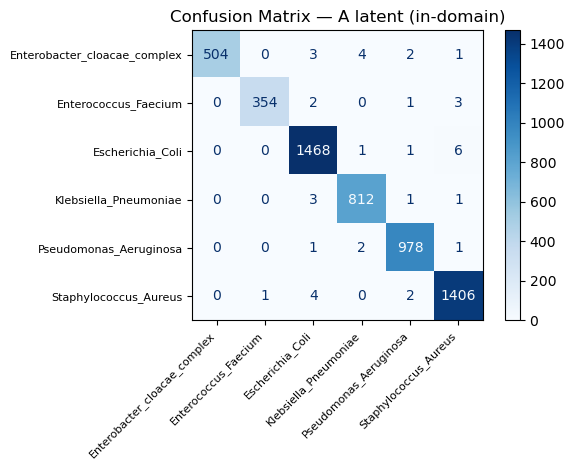


===== Metrics =====
Domain: D latent (cross-domain)
Balanced Accuracy: 0.8847
F1 Macro: 0.8298
Recall Macro: 0.8847
Specificity Macro: 0.9746



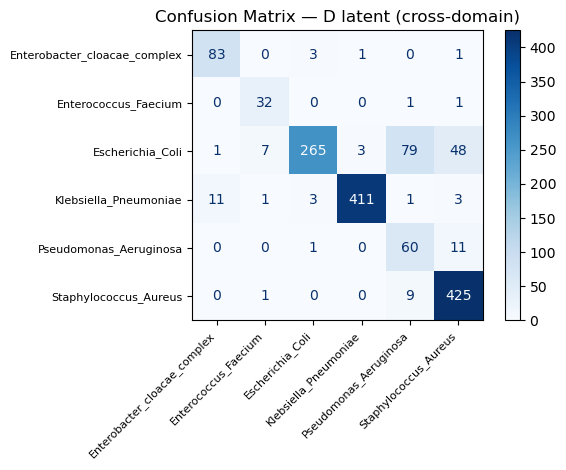

In [49]:
metrics_A_latent = metrics_report(Z_A_test, y_A_test, rf_latent, "A latent (in-domain)")
metrics_D_latent = metrics_report(Z_D_test, y_D_test, rf_latent, "D latent (cross-domain)")

print_metrics(metrics_A_latent)
print_metrics(metrics_D_latent)